In [1]:
# the libraries
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import glob
import os

import pandas as pd
import seaborn as sns
import cartopy.crs as ccrs
from scipy.stats import linregress
import time


from pylab import rcParams
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'

In [2]:
def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds


def build_weights(data, datadata, minvalue = -999, latlim = 90.):
    weights = datadata.isel(time = 0) > minvalue
    weights = weights *np.cos( np.deg2rad(data.lat))
    weights = weights*(abs(data.lat)<latlim)
    return weights


def anomaly(glbmean, weights, normalise = False, detrend = False):

    #nanoseconds per century required for fit
    ns_century = 1.e9*3600.*24.*365.*100.                # scaling: nono-seconds to century
    #detrend if desired
    if detrend:
        glbmean = glbmean.groupby('time.month').apply(detrend_monthly)

    
    databymth = glbmean.groupby("time.month")
    mthclim = databymth.mean("time")       # detrended climatological months (seasonal cycle)
    
    dataanom = databymth - mthclim          # detrended interannual annomaly
    if normalise:
        dataanom = dataanom/dataanom.std()
    dataanom = dataanom.rename('anom')   # change variable name
    return dataanom


def box_mean(data, datadata, weights):
    datadata_weighted = datadata.weighted(weights)
    weighted_mean = datadata_weighted.mean(('lat', 'lon'))
    return weighted_mean


# IPSL

# SST

In [3]:
ts_files = sorted(glob.glob('/bdd/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/historical/*/Amon/ts/gr/latest/*.nc'))

In [4]:
import xarray as xr

# Initialize a dictionary to store Niño 3.4 indices
nino34_indices = {}

# Loop through the first three files in ts_files
for fp in ts_files:
    with xr.open_dataset(fp) as ds:
        # Select the region for Niño 3.4
        sst34 = ds.sel(lon=slice(360-170.,360-120.), lat=slice(-5,5))

        # Compute sst weights
        sst_weights = build_weights(sst34, sst34.ts)

        # Compute box mean
        sst_boxmean = box_mean(sst34, sst34.ts, sst_weights)

        # Compute anomalies as Niño 3.4 index
        nino34_index = anomaly(sst_boxmean, sst_weights, detrend=False)

        nino34 = nino34_index.where(nino34_index.time.dt.month.isin([10,11,12])).groupby('time.year').mean()

        # Add the Niño 3.4 index to the dictionary
        nino34_indices[fp[-29:-19]] = nino34/nino34.std()
        
# Convert the dictionary to xarray Dataset
nino34_ipsl = xr.Dataset(nino34_indices)


In [5]:
nino34_ipsl.to_netcdf('/data/jmex/output/models/ipsl/nino34_ipsl.nc')

# tp

In [6]:
tp_files = sorted(glob.glob('/bdd/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/historical/*/Amon/pr/gr/latest/*.nc'))

In [7]:
import xarray as xr

# Initialize a dictionary to store Niño 3.4 indices
tps = {}

# Loop through the first three files in ts_files
for fp in tp_files:
    with xr.open_dataset(fp) as ds:
         
        #select west
        tp_west = ds.sel(lat = slice(-20,20), lon = slice(130, 150))

        tp_weights = np.cos(np.deg2rad(tp_west.lat))
        tp_west_mean = box_mean(tp_west, tp_west.pr, tp_weights).rolling(time = 3, center = True).mean()


        # Compute anomalies as Niño 3.4 index
        tp = anomaly(tp_west_mean, tp_weights, detrend = False)
        tp = tp.groupby('time.year').mean()*24*3600
        # Add the Niño 3.4 index to the dictionary
        tps[fp[-29:-19]] = tp/tp.std()

# Convert the dictionary to xarray Dataset
tp_ipsl = xr.Dataset(tps)


In [8]:
tp_ipsl.to_netcdf('/data/jmex/output/models/ipsl/tp_ipsl.nc')

# T2m

In [9]:
tas_files = sorted(glob.glob('/bdd/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/historical/*/Amon/tas/gr/latest/*.nc'))

In [10]:

# Initialize a dictionary to store Niño 3.4 indices
tass = {}

# Loop through the first three files in ts_files
for fp in tas_files:
    with xr.open_dataset(fp) as ds:
        
        w = np.cos(np.deg2rad(ds.lat))

        gt = ds.tas.weighted(w).mean(['lat', 'lon'])

        #caluclate difference
        gt_y = gt.groupby('time.year').mean()
        gt_y = gt_y - gt.mean()

        dt = gt_y-gt_y.roll(year = 1)

        # Add the dgsa to the dictionary
        tass[fp[-29:-19]] = dt/dt.std()

# Convert the dictionary to xarray Dataset
tas_ipsl = xr.Dataset(tass)


In [11]:
tas_ipsl.to_netcdf('/data/jmex/output/models/ipsl/tas_ipsl.nc')

In [3]:
tas_ipsl = xr.open_dataset('/data/jmex/output/models/ipsl/tas_ipsl.nc')
tp_ipsl = xr.open_dataset('/data/jmex/output/models/ipsl/tp_ipsl.nc')
nino34_ipsl = xr.open_dataset('/data/jmex/output/models/ipsl/nino34_ipsl.nc')

# MPI-M

In [198]:

# List of all subdirectories
subdirectories = [
    'r10i1p1f1', 'r11i1p1f1', 'r12i1p1f1', 'r13i1p1f1', 'r14i1p1f1',
    'r15i1p1f1', 'r16i1p1f1', 'r17i1p1f1', 'r18i1p1f1', 'r19i1p1f1',
    'r1i1p1f1', 'r1i2000p1f1', 'r20i1p1f1', 'r21i1p1f1', 'r22i1p1f1',
    'r23i1p1f1', 'r24i1p1f1', 'r25i1p1f1', 'r26i1p1f1', 'r27i1p1f1',
    'r28i1p1f1', 'r29i1p1f1', 'r2i1p1f1', 'r30i1p1f1', 'r31i1p1f1',
    'r32i1p1f1', 'r33i1p1f1', 'r34i1p1f1', 'r35i1p1f1', 'r36i1p1f1',
    'r37i1p1f1', 'r38i1p1f1', 'r39i1p1f1', 'r3i1p1f1', 'r40i1p1f1',
    'r41i1p1f1', 'r42i1p1f1', 'r43i1p1f1', 'r44i1p1f1', 'r45i1p1f1',
    'r46i1p1f1', 'r47i1p1f1', 'r48i1p1f1', 'r49i1p1f1', 'r4i1p1f1',
    'r50i1p1f1', 'r5i1p1f1', 'r6i1p1f1', 'r7i1p1f1', 'r8i1p1f1',
    'r9i1p1f1'
]

# SST

In [199]:

# Initialize a dictionary to store Niño 3.4 indices
nino34s = {}

# Base path to the files
base_path = '/bdd/CMIP6/CMIP/MPI-M/MPI-ESM1-2-LR/historical/'

# Process each subdirectory
for subdir in subdirectories:
    # Construct the path to the files in the current subdirectory
    file_pattern = os.path.join(base_path, subdir, 'Amon', 'ts', 'gn', 'latest', '*.nc')
    
    # Find all files in the current subdirectory
    file_list = glob.glob(file_pattern)
    
    # Concatenate all files in the current subdirectory
    if file_list:
        print(subdir)
        ds_concatenated = xr.open_mfdataset(file_list, combine='by_coords')
        sst34 = ds_concatenated.sel(lon = slice(360-170.,360-120.), lat=slice(-5,5))
        # Perform your operations on the concatenated dataset
        w = np.cos(np.deg2rad(sst34.lat))
        
        #compute mean
        sst34 = sst34.ts.weighted(w).mean(['lat','lon'])
        #cpmpute anom
        sst34 = sst34.groupby('time.month') - sst34.groupby('time.month').mean()
        
        #compute index
        nino34 = sst34.where(sst34.time.dt.month.isin([10,11,12])).groupby('time.year').mean()

        # Add the result to the dictionary
        nino34s[subdir] = nino34 / nino34.std()
        

# Convert the dictionary to xarray Dataset
nino34_mpi = xr.Dataset(nino34s)

# Optional: Save the dataset to a file
#tas_mpi.to_netcdf('tas_mpi.nc')


r10i1p1f1


/home/jmex/.conda/envs/myenv-3.9/lib/python3.9/site-packages/xarray/core/indexing.py:1228: PerformanceWarning: Slicing with an out-of-order index is generating 19 times more chunks
  return self.array[key]


r1i1p1f1


/home/jmex/.conda/envs/myenv-3.9/lib/python3.9/site-packages/xarray/core/indexing.py:1228: PerformanceWarning: Slicing with an out-of-order index is generating 19 times more chunks
  return self.array[key]


r2i1p1f1


...

/home/jmex/.conda/envs/myenv-3.9/lib/python3.9/site-packages/xarray/core/indexing.py:1228: PerformanceWarning: Slicing with an out-of-order index is generating 19 times more chunks
  return self.array[key]


r8i1p1f1


/home/jmex/.conda/envs/myenv-3.9/lib/python3.9/site-packages/xarray/core/indexing.py:1228: PerformanceWarning: Slicing with an out-of-order index is generating 19 times more chunks
  return self.array[key]


r9i1p1f1


/home/jmex/.conda/envs/myenv-3.9/lib/python3.9/site-packages/xarray/core/indexing.py:1228: PerformanceWarning: Slicing with an out-of-order index is generating 19 times more chunks
  return self.array[key]


In [200]:
nino34_mpi.to_netcdf('/data/jmex/output/models/mpim/nino34_mpi.nc')

# tp

In [201]:


# Initialize a dictionary to store Niño 3.4 indices
tps = {}

# Base path to the files
base_path = '/bdd/CMIP6/CMIP/MPI-M/MPI-ESM1-2-LR/historical/'

# Process each subdirectory
for subdir in subdirectories:
    # Construct the path to the files in the current subdirectory
    file_pattern = os.path.join(base_path, subdir, 'Amon', 'pr', 'gn', 'latest', '*.nc')
    
    # Find all files in the current subdirectory
    file_list = glob.glob(file_pattern)
    
    # Concatenate all files in the current subdirectory
    if file_list:
        print(subdir)
        ds_concatenated = xr.open_mfdataset(file_list, combine='by_coords')
        
        #select west
        tp_west = ds_concatenated.sel(lat = slice(-20,20), lon = slice(130, 150))

        tp_weights = np.cos(np.deg2rad(tp_west.lat))
        #compute mean
        tp =tp_west.pr.weighted(tp_weights).mean(['lat','lon'])
        #compute annyal mean
        tp = tp.groupby('time.year').mean()*24*3600
        #compute anom
        tp = tp-tp.mean()

        # Add the result to the dictionary
        tps[subdir] = tp / tp.std()
        

# Convert the dictionary to xarray Dataset
tp_mpi = xr.Dataset(tps)

# Optional: Save the dataset to a file
#tas_mpi.to_netcdf('tas_mpi.nc')


r10i1p1f1
r1i1p1f1
r2i1p1f1
r3i1p1f1
r4i1p1f1
r5i1p1f1
r6i1p1f1
r7i1p1f1
r8i1p1f1
r9i1p1f1


In [202]:
tp_mpi.to_netcdf('/data/jmex/output/models/mpim/tp_mpi.nc')

# T2m

In [203]:



# Initialize a dictionary to store Niño 3.4 indices
tass = {}

# Base path to the files
base_path = '/bdd/CMIP6/CMIP/MPI-M/MPI-ESM1-2-LR/historical/'

# Process each subdirectory
for subdir in subdirectories:
    # Construct the path to the files in the current subdirectory
    file_pattern = os.path.join(base_path, subdir, 'Amon', 'tas', 'gn', 'latest', '*.nc')
    
    # Find all files in the current subdirectory
    file_list = glob.glob(file_pattern)
    
    # Concatenate all files in the current subdirectory
    if file_list:
        print(subdir)
        ds_concatenated = xr.open_mfdataset(file_list, combine='by_coords')
        
        # Perform your operations on the concatenated dataset
        w = np.cos(np.deg2rad(ds_concatenated.lat))

        gt = ds_concatenated.tas.weighted(w).mean(['lat', 'lon'])

        # Calculate difference
        gt_y = gt.groupby('time.year').mean()
        gt_y = gt_y - gt.mean()

        dt = gt_y - gt_y.roll(year=1)

        # Add the result to the dictionary
        tass[subdir] = dt / dt.std()
        

# Convert the dictionary to xarray Dataset
tas_mpi = xr.Dataset(tass)

# Optional: Save the dataset to a file
#tas_mpi.to_netcdf('tas_mpi.nc')


r10i1p1f1
r1i1p1f1
r2i1p1f1
r3i1p1f1
r4i1p1f1
r5i1p1f1
r6i1p1f1
r7i1p1f1
r8i1p1f1
r9i1p1f1


In [204]:
tas_mpi.to_netcdf('/data/jmex/output/models/mpim/tas_mpi.nc')

## make figure

In [8]:
tas_mpi = xr.open_dataset('/data/jmex/output/models/mpim/tas_mpi.nc')
tp_mpi = xr.open_dataset('/data/jmex/output/models/mpim/tp_mpi.nc')
nino34_mpi = xr.open_dataset('/data/jmex/output/models/mpim/nino34_mpi.nc')

Ratio of points inside the shaded area: 0.035


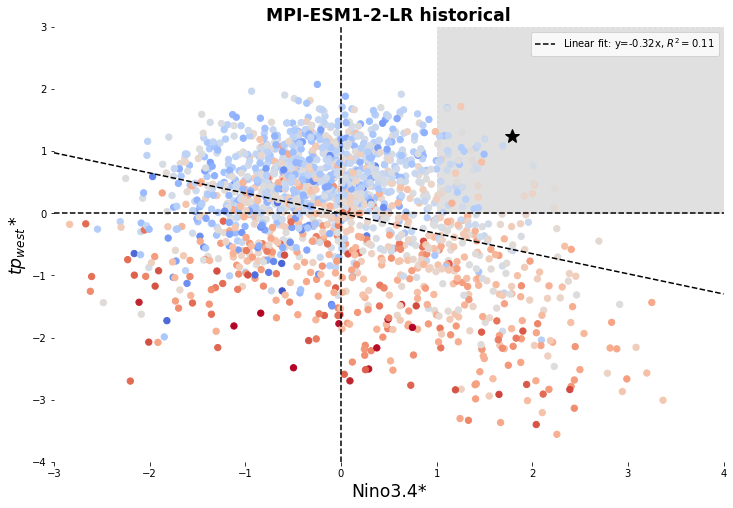

In [48]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(1, 1, figsize=(12, 8))

ax.set_ylim(-4, 3)
ax.set_xlim(-3, 4)
ax.set_ylabel(r'$tp_{west}*$', fontsize = 'xx-large')
ax.set_xlabel(r'Nino3.4*', fontweight='normal', fontsize = 'xx-large')
ax.set_title('MPI-ESM1-2-LR historical')

ax.axhline(0, linestyle='--', c='k')
ax.axvline(0, linestyle='--', c='k')

# Define the coordinates and dimensions of the shaded area
x_min, x_max = 1, 4
y_min, y_max = 0, 3

# Shade the rectangular area
ax.fill_betweenx(y=[y_min, y_max], x1=x_min, x2=x_max, color='lightgrey', alpha=0.7, linestyle='--')

# Collect all points to fit the regression line
all_nino34 = []
all_tp = []

# Example data plotting (assuming tp_mpi, nino34_mpi, and tas_mpi are defined)
total_points = 0
points_inside = 0
for key in list(tp_mpi.data_vars.keys()):
    cmap = ax.scatter(y=tp_mpi[key], x=nino34_mpi[key], c=nino34_mpi[key].roll(year = 1), cmap='coolwarm', s=40, vmin=-3, vmax=3)
    
    # Calculate the points inside the shaded area for the current dataset
    inside = ((nino34_mpi[key] >= x_min) & (nino34_mpi[key] <= x_max) &
              (tp_mpi[key] >= y_min) & (tp_mpi[key] <= y_max))
    
    points_inside += np.sum(inside)
    total_points += len(nino34_mpi[key])
    
    # Collect points for regression
    all_nino34.extend(nino34_mpi[key].data)
    all_tp.extend(tp_mpi[key].data)


# Fit a regression line to the collected points
slope, intercept, r_value, p_value, std_err = linregress(all_nino34, all_tp)

# Plot the regression line
x_vals = np.array(ax.get_xlim())
y_vals = intercept + slope * x_vals
ax.plot(x_vals, y_vals, '--', color='k', label=f'Linear fit: y={slope:.2f}x, $R^2={r_value**2:.2f}$')


ax.plot(1.79, 1.25, marker='*', color='black', markersize=15, linestyle = ' ')


# Calculate the ratio of points inside the shaded area to the total number of points
ratio = points_inside / total_points
print(f"Ratio of points inside the shaded area: {ratio.data:.3f}")

# Hide all spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Add colorbar
#fig.colorbar(cmap, ax=ax, label=r'Δ GSAT', use_gridspec=True, orientation = 'horizontal', shrink = 0.6, extend = 'both')
ax.legend()
plt.show()


In [40]:
tp_mpi[key].data

array([-5.69812120e-01,  1.82245671e-02,  3.38028246e-02, -1.74291321e-01,
        5.98562034e-01, -3.37008161e-01,  9.02060382e-01,  2.13714442e-01,
        1.77165896e+00,  1.01937930e+00, -9.93000793e-01,  4.90935529e-01,
        7.55260425e-02, -9.98281429e-02,  3.28030892e-01,  6.66618066e-01,
        1.15866183e+00,  6.13774160e-01, -1.01137360e+00, -7.61337496e-01,
        4.41172324e-02,  6.13430858e-01,  1.46962803e+00,  1.09212540e+00,
       -7.40564765e-01,  3.56083514e-01, -5.37447379e-02,  1.05248815e+00,
       -2.07331841e-02, -1.57250063e+00,  3.86464590e-02,  4.79005499e-01,
        3.29079042e-01,  2.31430339e-01, -5.70854553e-01,  2.77930770e-01,
        8.06617505e-03,  9.88021907e-01,  8.08171997e-01,  1.14916112e+00,
        4.42158287e-01, -1.30162426e+00, -3.33241243e+00, -2.07723791e+00,
       -3.10876282e-01,  1.16133890e+00,  1.33316759e+00,  3.90930205e-01,
       -1.89187045e+00,  3.26978357e-01, -3.98842444e-01,  1.05310685e+00,
       -1.68240085e+00, -

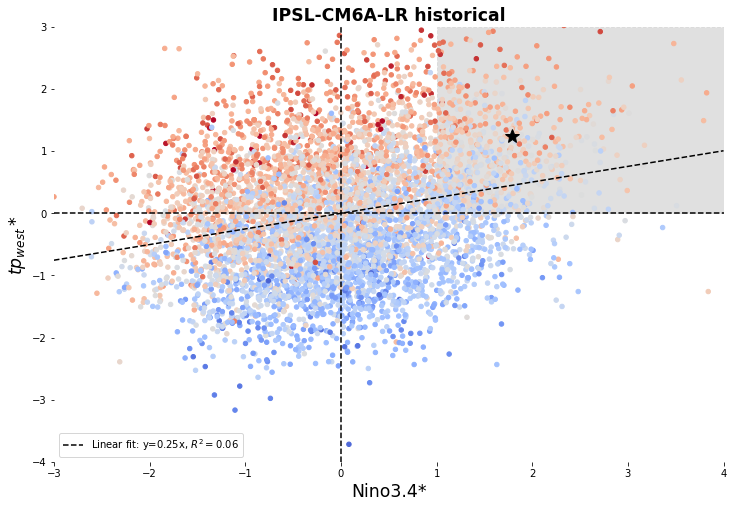

In [49]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(12, 8))

ax.set_ylim(-4, 3)
ax.set_xlim(-3, 4)
ax.set_ylabel(r'$tp_{west}*$', fontsize = 'xx-large')
ax.set_xlabel(r'Nino3.4*', fontweight='normal', fontsize = 'xx-large')
ax.set_title('IPSL-CM6A-LR historical')

ax.axhline(0, linestyle='--', c='k')
ax.axvline(0, linestyle='--', c='k')

# Define the coordinates and dimensions of the shaded area
x_min, x_max = 1, 4
y_min, y_max = 0, 3

# Collect all points to fit the regression line
all_nino34 = []
all_tp = []

# Shade the rectangular area
ax.fill_betweenx(y=[y_min, y_max], x1=x_min, x2=x_max, color='lightgrey', alpha=0.7, linestyle='--')

# Example data plotting (assuming tp_ipsl, nino34_ipsl, and tas_ipsl are defined)
for key in list(tp_ipsl.data_vars.keys()):
    cmap = ax.scatter(y=tp_ipsl[key], x=nino34_ipsl[key], c=nino34_ipsl[key].roll(year = 1), cmap='coolwarm', s=20, vmin=-3, vmax=3)
    # Collect points for regression
    all_nino34.extend(nino34_ipsl[key].data)
    all_tp.extend(tp_ipsl[key].data)

    
# Fit a regression line to the collected points
slope, intercept, r_value, p_value, std_err = linregress(all_nino34, all_tp)

# Plot the regression line
x_vals = np.array(ax.get_xlim())
y_vals = intercept + slope * x_vals
ax.plot(x_vals, y_vals, '--', color='k', label=f'Linear fit: y={slope:.2f}x, $R^2={r_value**2:.2f}$')

ax.plot(1.79, 1.25, marker='*', color='black', markersize=15, linestyle = ' ')


# Hide all spines
for spine in ax.spines.values():
    spine.set_visible(False)

    
    
# Add legend
ax.legend()
# Add colorbar
#fig.colorbar(cmap, ax=ax, label=r'Nino3.4 Year[-1]', use_gridspec=True, orientation='horizontal', shrink=0.6, extend='both',)


# Show the plot
plt.show()


In [10]:
# Calculate the ratio of points inside the shaded area to the total number of points
ratio = points_inside / total_points
print(f"Ratio of points inside the shaded area: {ratio:.3f}")


TypeError: unsupported format string passed to DataArray.__format__